# Text to Locations
Compute cosine similarity between a text prompt and a gallery of locations, then visualize as a heatmap.

In [21]:
import argparse
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from models.model import TextLocationModel
from models.utils import make_text_encoder, make_location_encoder

## Config
Set your paths and prompt here.

In [22]:
CSV_PATH = "/home/libe2152/data/s2-100k/index.csv"   # CSV with lat/lon columns
MODEL_PATH = "/home/libe2152/outputs/explainable-earth-embeddings/open_clip/best/txt-open_clip__loc-satclip__tproj-mlp__lproj-none__loss-mse__lr-0.0001/best.pt"     # checkpoint
OUT_PATH = "text_to_locations.png"

PROMPT = "A satellite image of cropland"

## Load gallery

In [23]:
df = pd.read_csv(CSV_PATH)
lat_col = next(c for c in df.columns if "lat" in c.lower())
lon_col = next(c for c in df.columns if "lon" in c.lower())
lats, lons = df[lat_col].values, df[lon_col].values
print(f"Loaded {len(lats)} locations")

Loaded 100000 locations


## Load model

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
a = argparse.Namespace(**ckpt["args"])
text_enc = make_text_encoder(
    a.text_encoder, a.text_projection, a.shared_dim, a.text_finetune_mode,
    num_hidden_layers=a.text_proj_hidden_layers,
    num_hidden_features=a.text_proj_hidden_features,
    nonlinearity=a.text_nonlinearity, precomputed=False,
)
loc_enc = make_location_encoder(
    a.location_encoder, a.location_projection, a.shared_dim, a.loc_finetune_mode,
    num_hidden_layers=a.loc_proj_hidden_layers,
    num_hidden_features=a.loc_proj_hidden_features,
    nonlinearity=a.loc_nonlinearity, precomputed=False,
)
model = TextLocationModel(text_enc, loc_enc).to(device)
model.load_state_dict(ckpt["model"], strict=False)
model.eval()
print("Model loaded")

Using device: cuda


/home/libe2152/miniconda3/envs/fai/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


using pretrained moco vit16
Model loaded


## Encode locations (run once)

In [25]:
coords = torch.tensor(np.stack([lats, lons], axis=1), dtype=torch.float32).to(device)

with torch.no_grad():
    loc_embs = F.normalize(model.location_model(coords).float(), dim=-1)

print(f"Location embeddings: {loc_embs.shape}")

Location embeddings: torch.Size([100000, 256])


## Encode prompt and compute similarity
Re-run this cell with different `PROMPT` values to experiment.

In [26]:
with torch.no_grad():
    txt_emb = model.text_model_predict([PROMPT])

sims = (loc_embs @ txt_emb.T).squeeze().cpu().numpy()
print(f"Similarity range: [{sims.min():.3f}, {sims.max():.3f}]")

Similarity range: [-0.652, 0.756]


## Plot heatmap

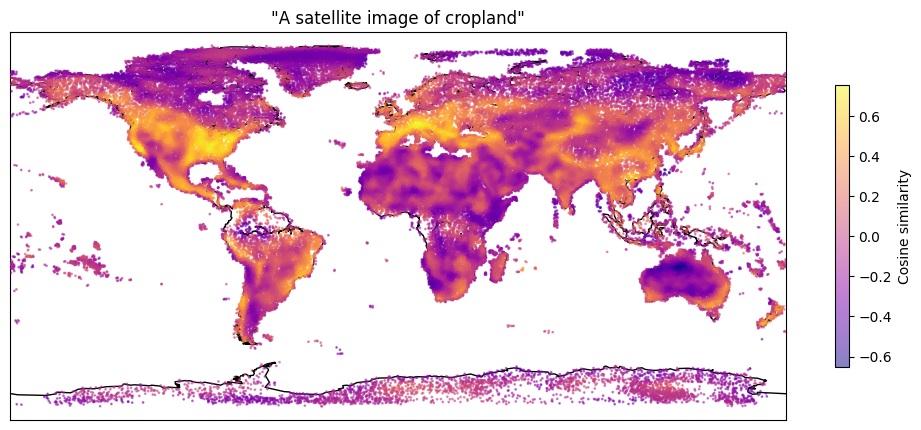

Saved to text_to_locations.png


In [27]:
fig, ax = plt.subplots(1, figsize=(10, 5))
m = Basemap(projection="cyl", resolution="c", ax=ax)
m.drawcoastlines()
sc = ax.scatter(lons, lats, c=sims, cmap="plasma", s=1, alpha=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label="Cosine similarity", shrink=0.6)
ax.set_title(f'"{PROMPT}"')
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUT_PATH}")